
Sections:

1. Inferential Statistics

2. Sampling
* Population
* Sample
* Parameter
* Statistic
* Random sampling

3. Sampling Distribution

4. Central Limit Theorem

5. Confidence Intervals

6. Hypothesis Testing
* Null hypothesis
* Alternative hypothesis
* Significance level
* Test statistic
* p-value

7. Statistical Tests
* One-sample t-test
* Two-sample t-test
* Chi-square test


## 1.0 Inferential Statistics

Inferential statistics is the process of using data from a sample to make conclusions or estimates about a larger population.

While descriptive statistics focuses on summarizing the data we have, inferential statistics helps us go further by using a sample to learn about a population.

For example, instead of studying the salary of every employee in a population, we can select a sample of employees, analyze their salaries, and use the results to make an inference about the larger population.

In this notebook, we will use the employee data to demonstrate the main concepts and methods of inferential statistics, including sampling, sampling distributions, the Central Limit Theorem, confidence intervals, hypothesis testing, correlation...


## 2.0 Sampling

### Population, Sample, Parameter and Statistic

Before applying inferential statistics, it is important to understand four basic concepts: **population, sample, parameter, and statistic**.


### Summary table

| Concept        | Meaning                                      | Example                |
| -------------- | -------------------------------------------- | ---------------------- |
| **Population** | The entire group being studied               | 10,000 employees       |
| **Sample**     | A smaller group selected from the population | 200 employees          |
| **Parameter**  | A numerical value describing the population  | Population mean salary |
| **Statistic**  | A numerical value describing the sample      | Sample mean salary     |


#### Why Sampling is Important

Sampling involves selecting a smaller group of observations from a population for analysis.

Studying the entire population may require more time and resources, so a sample can be used to make estimates and draw conclusions about the entire population.

For a sample to provide useful information about the population, it should be selected in a way that reduces bias and gives different members of the population a fair chance of being included.


### Random Sampling

**Random sampling** is a method where members of a population are selected randomly.

This helps reduce selection bias because each employee has an equal chance of being selected.

In this analysis, we will use random sampling to select a smaller group of employees from our population of 10,000 employees.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv("./Data/Employers_data.csv")

#### Creating a Random Sample from the Employee Data

In [3]:
# Select a random sample of 200 employees
sample_df = df.sample(n=200, random_state=42)

# Display the first five rows
sample_df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
6252,6253,Paula Hernandez,41,Female,Engineering,Manager,18,Master,San Francisco,135000
4684,4685,Mary Hodges,29,Female,HR,Analyst,6,Master,New York,70000
1731,1732,Larry Menzies,25,Male,Finance,Analyst,4,Bachelor,Austin,65000
4742,4743,James Wilson,35,Male,Engineering,Manager,12,Master,San Francisco,125000
4521,4522,Donald Crawford,44,Male,Engineering,Manager,21,Master,Chicago,140000


* The **random_state=42** makes the sampling reproducible, meaning we will get the same sample each time we run the code.

In [4]:
# Check the sample size
sample_df.shape

(200, 10)

In [5]:
# Compare the population and sample
print("Population size:", len(df))
print("Sample size:", len(sample_df))

Population size: 10000
Sample size: 200


**Observation**

A random sample of 200 employees has been selected from the population of 10,000 employees.

We will use this sample to demonstrate **sampling distributions**, **confidence intervals**, and **hypothesis testing.**

## 3.0 Sampling Distribution

A **sampling distribution** is the distribution of a statistic calculated from many different samples taken from the same population.

For example, if we repeatedly select samples of employees and calculate the mean salary for each sample, the collection of those Sample Means forms a **sampling distribution**.

A sampling distribution helps us understand how samples vary from one sample to another.


* Since our population contains 10,000 employees, we can repeatedly take random samples and calculate the mean salary for each sample.


In [6]:
# Let's take 1,000 samples, with each sample containing 200 employees.
sample_means = []

for i in range(1000):
    sample = df.sample(n=200)
    sample_means.append(sample["Salary"].mean())


# converting the samples into a DataFrame
sampling_distribution = pd.DataFrame({
    "Sample_Mean_Salary": sample_means
})

sampling_distribution.head()

,Sample_Mean_Salary
0,117600.0
1,116100.0
2,113725.0
3,109825.0
4,116250.0


In [7]:
sampling_distribution.shape

(1000, 1)

* We have 1,000 Sample Means from the distribution.

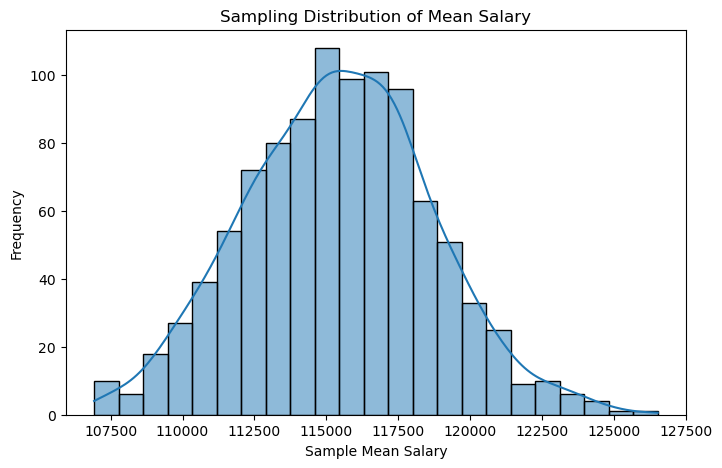

In [8]:
# Visualizing the Sampling Distribution for the sample means
plt.figure(figsize=(8, 5))

sns.histplot(
    data=sampling_distribution,
    x="Sample_Mean_Salary",
    kde=True
)

plt.title("Sampling Distribution of Mean Salary")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.show()

#### Comparing the Mean and Standard Deviation of the Sample Means with the Population Mean

For samples

In [9]:
sample_mean = sampling_distribution["Sample_Mean_Salary"].mean()
sample_std = sampling_distribution["Sample_Mean_Salary"].std()

print("Sample Mean Salary:", sample_mean)
print("Sample Standard Deviation:", sample_std)

Sample Mean Salary: 115423.5
Sample Standard Deviation: 3244.182673836543


For Population

In [10]:
population_mean = df["Salary"].mean()
population_std = df["Salary"].std()

print("Population Mean Salary:", population_mean)
print("Population Standard Deviation:", population_std)

Population Mean Salary: 115381.5
Population Standard Deviation: 46066.139046664925


#### Observation

* The population mean salary is **115,381.50**, while the Sample Mean Salary  is **115,357.0**.
* The two values are very close, showing that the mean of the sample means provides a good estimate of the entire employee population mean.
* The population standard deviation is 46,066.14, while the sample standard deviaton is 3,107.30.
* The sample means vary less because each mean is calculated from a sample of 200 employees.
* This shows that larger samples produce more stable estimates of the population mean.


###  Why Sample Means Vary

Different random samples contain different employees. Because of this, the mean calculated from one sample may be different from the mean calculated from another sample.

For example:

* Sample 1 may have a mean salary of 116,000.
* Sample 2 may have a mean salary of 113,500.
* Sample 3 may have a mean salary of 115,800.

However, when many samples are taken, the sample means tend to form a stable distribution around the population mean.

This idea is important because inferential statistics uses sample results to estimate and make conclusions about the population.


## 4.0 Central Limit Theorem

* In simple terms the Central Limit Theorem (CLT) states that when we take many large samples and calculate their means, the sample means tend to form a bell-shaped distribution.

The Central Limit Theorem is important because it allows us to use sample data to make conclusions about a population.

It provides the foundation for methods such as:

* Confidence intervals
* Hypothesis testing
* Estimating population parameters

In our analysis, we used 1,000 samples of 200 employees. The distribution of their sample means can be used to demonstrate how the Central Limit Theorem works.

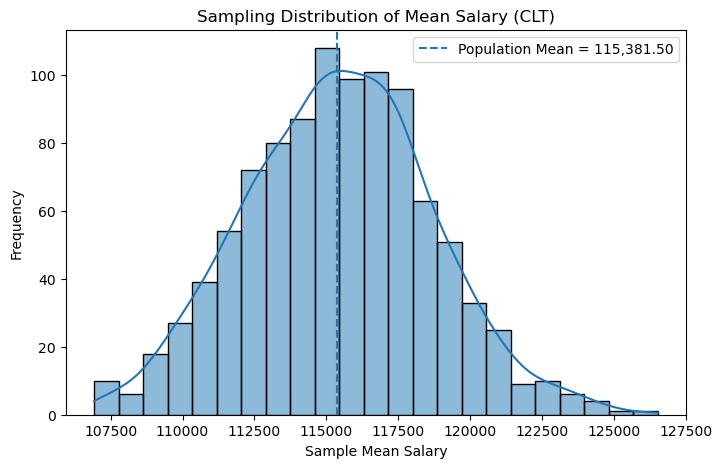

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=sampling_distribution,
    x="Sample_Mean_Salary",
    kde=True
)

plt.axvline(
    population_mean,
    linestyle="--",
    label=f"Population Mean = {population_mean:,.2f}"
)

plt.title("Sampling Distribution of Mean Salary (CLT)")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

From the graph
* The sample Means form a distribution that is approximately bell-shaped.
* **The distribution is centered close to the population mean salary**.
* This demonstrates the **Central Limit Theorem** using the employee salaries data.
* The CLT helps explain why sample means can be used to make inferences about a population.


### 5.0 Confidence Intervals

A confidence interval is a range of values used to estimate a population parameter, such as the population mean.

A sample mean gives us a point estimate of the population mean, but it may not be exactly equal to the true population mean. **A confidence interval** gives us a range around the sample mean to account for this uncertainty.

For example, we can use the mean salary from our sample of 200 employees to estimate the mean salary of the entire population. Instead of giving only one value, we can calculate a range that is likely to contain the true population mean.

The width of a confidence interval depends on factors such as the sample size, the spread of the data, and the chosen confidence level. A higher confidence level produces a wider interval.

A **95% confidence level** will be used below to estimate the population mean salary from our sample of 200 employees.


In [12]:
# Calculate the 95% confidence interval
confidence_interval = (
    np.percentile(sampling_distribution["Sample_Mean_Salary"], 2.5),
    np.percentile(sampling_distribution["Sample_Mean_Salary"], 97.5)
)

# Get the confidence interval limits
lower_bound, upper_bound = confidence_interval



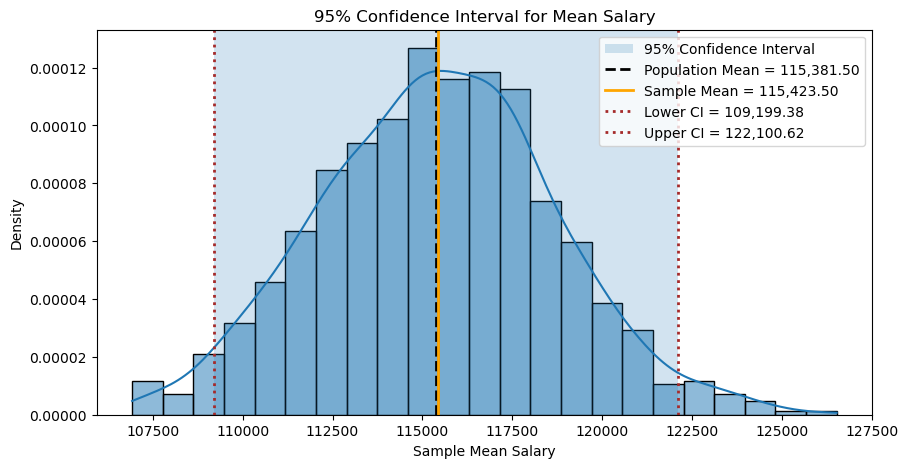

In [14]:
plt.figure(figsize=(10, 5))

# Bell-shaped sampling distribution
sns.histplot(
    sampling_distribution["Sample_Mean_Salary"],
    kde=True,
    stat="density"
)

# Shade the 95% confidence interval
plt.axvspan(
    lower_bound,
    upper_bound,
    alpha=0.2,
    label="95% Confidence Interval"
)

# Population mean
plt.axvline(
    population_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Population Mean = {population_mean:,.2f}"
)

# Sample mean
plt.axvline(
    sample_mean,
    color="orange",
    linestyle="-",
    linewidth=2,
    label=f"Sample Mean = {sample_mean:,.2f}"
)

# Lower confidence limit
plt.axvline(
    lower_bound,
    color="brown",
    linestyle=":",
    linewidth=2,
    label=f"Lower CI = {lower_bound:,.2f}"
)

# Upper confidence limit
plt.axvline(
    upper_bound,
    color="brown",
    linestyle=":",
    linewidth=2,
    label=f"Upper CI = {upper_bound:,.2f}"
)

plt.title("95% Confidence Interval for Mean Salary")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Density")
plt.legend()
plt.show()

* From the graph, the **sample mean salary** is 115,346.52 , while the **population mean salary** is 115,381.50 The 95% confidence interval ranges from (108,698.12.75 to 121,853.12) and the population mean falls within this interval.
* Therefore, we are 95% confident that the interval 108,698.12.75 - 121,853.12 captures the true population mean salary. 

## 6.0 Hypothesis Testing

Hypothesis testing is a statistical method used to determine whether there is enough evidence to support a claim about a population.

### 6.1 Null Hypothesis & Alternative Hypothesis

* **Null Hypothesis (H₀):** Assumes there is no significant difference or relationship.
* **Alternative Hypothesis (H₁):** Suggests that a significant difference or relationship exists.

A hypothesis test uses sample data to decide whether to **reject the null hypothesis** or **fail to reject it**.
